# Data Cleaning Notebook

In [37]:
# install packages if necessary
%pip install pandas geopandas matplotlib plotnine ggplot seaborn


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
import zipfile

## The `load_data()` function

- Loads in city data, the [geojson file](https://data.sfgov.org/Geographic-Locations-and-Boundaries/Bay-Area-County-Polygons/wamw-vt4s/data_preview), and crash data
- Converts data to have valid coordinates
- Returns all files

In [39]:
def load_data(stop_path, geo_path, crash_path, census_path):
    
    # unzip stop and crash data
    with zipfile.ZipFile(stop_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        df = pd.read_csv(z.open(csv_file))
    with zipfile.ZipFile(crash_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        crash_df = pd.read_csv(z.open(csv_file))
    

    # get boundaries of city 
    city_df = gpd.read_file(geo_path)
    census_df = gpd.read_file(census_path)
    
    # get locations of all stops, crashes from the city's dataset
    stops_df = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lng"], df["lat"]),
        crs="EPSG:4326"
    )
    crash_df = gpd.GeoDataFrame(
        crash_df,
        geometry=gpd.points_from_xy(crash_df["tb_longitude"], crash_df["tb_latitude"]),
        crs="EPSG:4326"
    )
    
    # Print coordinate reference system to verify correct locations
    print("Shapefile CRS:", city_df.crs)
    print("Police Stop Data CRS:", stops_df.crs)
    print("Collision Data CRS:", crash_df.crs)
    print("Shapefile Census CRS:", census_df)
    
    return city_df, stops_df, crash_df, census_df

1. We manually add in the pathname for the Bay Area counties <font color='red'>(source?)</font> to see the extent of counties local to San Francisco. 
2. We also add the pathname for the [Stanford Open Policing project data](https://github.com/stanford-policylab/opp/blob/master/data_readme.md) and [San Francisco Traffic Crash dataset](https://data.sfgov.org/Public-Safety/Traffic-Crashes-Resulting-in-Injury/ubvf-ztfx/about_data) to obtain coordinates where stops and crashes occurred.

*Loading this data will assist us in determining if the coordinates logged in the Stanford Open Policing project data have been logged improperly or are irrelevant to our analyses.*

In [40]:
# change path names based on city/dataset
stop_df_path = r"../data/sf_police_stops_raw.csv.zip"
geo_path = r"../data/Bay_Area_County_Polygons.geojson"
crash_df_path = r"../data/collisions_raw_updated.csv.zip"
#crash_df_path = r"../data/collisions_raw.csv.zip"
census_df_path = r"../data/Census_2010_Tracts_20260219.geojson"

# load and view example data
city_boundaries, stops_df, crash_df, census_boundaries = load_data(stop_df_path, geo_path, crash_df_path, census_df_path)

city_boundaries.head()
census_boundaries.head()
stops_df.head()
crash_df.head()


/var/folders/sz/kfl22r0s7v3bf055gpl9hxkr0000gn/T/ipykernel_983/3770449683.py:6: DtypeWarning:

Columns (0: district) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/sz/kfl22r0s7v3bf055gpl9hxkr0000gn/T/ipykernel_983/3770449683.py:9: DtypeWarning:

Columns (0: officer_id) have mixed types. Specify dtype option on import or set low_memory=False.



Shapefile CRS: EPSG:4326
Police Stop Data CRS: EPSG:4326
Collision Data CRS: EPSG:4326
Shapefile Census CRS:                     :id           :version                      :created_at  \
0    row-pv7u_tutn.vstp  rv-dr4w~u6hw_4v87 2016-07-17 18:11:48.600000+00:00   
1    row-brcb~qfbw-z4cc  rv-9kem.srs9-rqjf 2016-07-17 18:11:48.600000+00:00   
2    row-scfa-fyx5.af4a  rv-vkue_cnt3-fps7 2016-07-17 18:11:48.600000+00:00   
3    row-sfsx.vaiz_5qgd  rv-x6b9~qrzs.ij8n 2016-07-17 18:11:48.600000+00:00   
4    row-cz6r-putx~4ctd  rv-uidu_sqk5_8jr3 2016-07-17 18:11:48.600000+00:00   
..                  ...                ...                              ...   
192  row-4dia~mxiz_mc46  rv-wnj6~t5im~gkcp 2016-07-17 18:11:48.600000+00:00   
193  row-xiib-38va_ti79  rv-cxx9~b2kh~2wvd 2016-07-17 18:11:48.600000+00:00   
194  row-nxud_582b~z4yi  rv-3sj9.xren_rpve 2016-07-17 18:11:48.600000+00:00   
195  row-z78t_z67f.efws  rv-fbyr~pq82.zy3y 2016-07-17 18:11:48.600000+00:00   
196  row-xmgp-kmts-pia

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,party2_dir_of_travel,party2_move_pre_acc,point,data_as_of,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district,geometry
0,28982,25186000,13150101.0,4639302,37.782932,-122.420856,SFPD-CROSSROADS,CITY STREET,2010 Jan 01 02:06:00 AM,2010 January 01,...,South,Stopped In Road,POINT (-122.420855669 37.782932212),2010 Jan 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 Jan 30 10:45:22 AM,Tenderloin,5.0,NORTHERN,POINT (-122.42086 37.78293)
1,3974,21647000,5087000.0,4576911,37.725067,-122.429108,SFPD-CROSSROADS,CITY STREET,2010 Jan 01 02:38:00 AM,2010 January 01,...,NaN,NaN,POINT (-122.429108221 37.725067478),2010 Jan 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 Jan 30 10:45:22 AM,Excelsior,11.0,INGLESIDE,POINT (-122.42911 37.72507)
2,3329,20659000,NaN,4584610,37.734797,-122.390694,SFPD-CROSSROADS,CITY STREET,2010 Jan 01 04:30:00 PM,2010 January 01,...,South,Proceeding Straight,POINT (-122.390693773 37.734797359),2010 Jan 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 Jan 30 10:45:22 AM,Bayview Hunters Point,10.0,BAYVIEW,POINT (-122.39069 37.7348)
3,31769,25222000,10568000.0,4564715,37.789592,-122.420488,SFPD-CROSSROADS,CITY STREET,2010 Jan 01 06:59:00 PM,2010 January 01,...,East,Proceeding Straight,POINT (-122.420487648 37.789591819),2010 Jan 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 Jan 30 10:45:22 AM,Nob Hill,3.0,NORTHERN,POINT (-122.42049 37.78959)
4,2796,20578000,10312000.0,4576959,37.723900,-122.401979,SFPD-CROSSROADS,CITY STREET,2010 Jan 02 04:50:00 PM,2010 January 02,...,NaN,NaN,POINT (-122.401978788 37.723900433),2010 Jan 02 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 Jan 30 10:45:22 AM,Portola,10.0,BAYVIEW,POINT (-122.40198 37.7239)


## Visualizing Raw Data Before Preprocessing

Before making any changes to the data, we want to see what it looks like to determine what preprocessing steps are necessary for our geospatial data processing pipeline. 

In [41]:
import plotly.express as px
import plotly.graph_objects as go
import json
import plotnine
from plotnine import *
from plotnine.data import *
import plotly.io as pio
pio.renderers.default = "browser"


### This is very laggy and clunky 

In [42]:
# Plot heatmap to show distribution of crashes and collisions from raw data
geojson = city_boundaries.__geo_interface__

# plot baselayer
fig = px.choropleth_map(
    city_boundaries,
    geojson=geojson,
    locations=city_boundaries.index,
    color_discrete_sequence=["lightgray"],
    map_style="carto-positron",
    zoom=8,
    center={"lat": 37.77, "lon": -122.42},
    opacity=0.4
)

# Police stop density
fig.add_trace(
    go.Densitymap(
        lat=stops_df.geometry.y,
        lon=stops_df.geometry.x,
        radius=5,
        colorscale="Blues",
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Stops"
    )
)

# Crash density
fig.add_trace(
    go.Densitymap(
        lat=crash_df.geometry.y,
        lon=crash_df.geometry.x,
        radius=5,
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Crashes"
    )
)

fig.update_layout(
    title="Police Stops and Collisions Density",
    hovermode=False,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

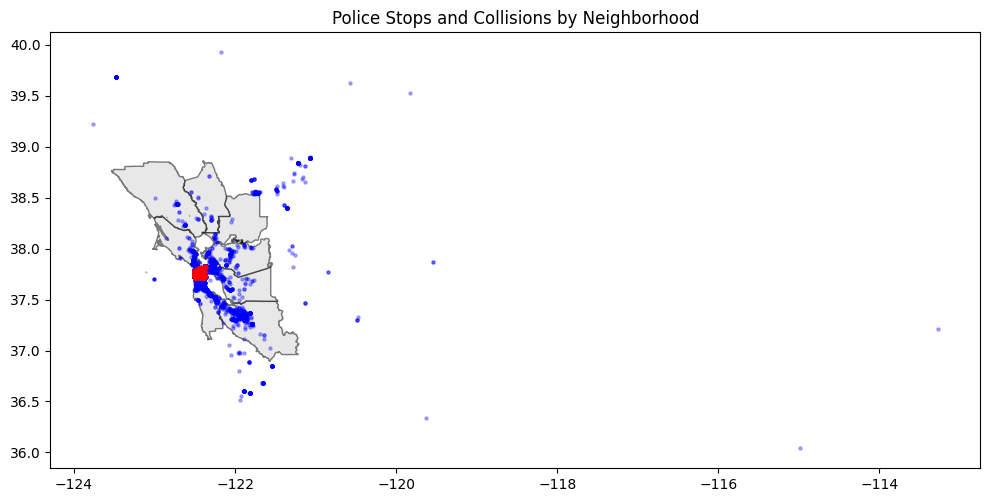

In [43]:
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
# plot bay area county boundaries
city_boundaries.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
# color county=='San Francisco' in city_boundaries a different color

# add stops and collisions
stops_df.plot(ax=ax, color='blue', markersize=5, alpha=0.3)
crash_df.plot(ax=ax, color='red', markersize=5, alpha=0.3)
plt.title("Police Stops and Collisions by Neighborhood")
plt.show()

We can see that there are several coordinates outside of the extent of San Francisco County. 
This leads us to believe these points have been recorded incorrectly, or that there are points  and should be removed from data before modeling. 

# Stop Preprocessing

## The `fix_coordinates()` function (Preprocess Location)

- Takes in the stop dataset and the city boundaries
- Calculates the bounds of the city
- Filters out points in the stop dataset that aren't within the city boundaries
- Returns a cleaned dataset

Since we are only interested in San Francisco County, we add it to our counties of interest in order to filter out data from other counties. 

In [44]:
# filter city to county of interest
counties_of_interest = ["San Francisco"]

# get number of coordinates within bounds
city_filtered = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
print("Total points:", len(stops_df))

min_x = city_filtered.total_bounds[0]
max_x = city_filtered.total_bounds[2]
min_y = city_filtered.total_bounds[1]
max_y = city_filtered.total_bounds[3]

print(f"Longitude: {min_x}, {max_x}\nLatitude: {min_y}, {max_y}")


Total points: 905070
Longitude: -123.10802700119842, -122.32768100246903
Latitude: 37.69306499862042, 37.863425998396984


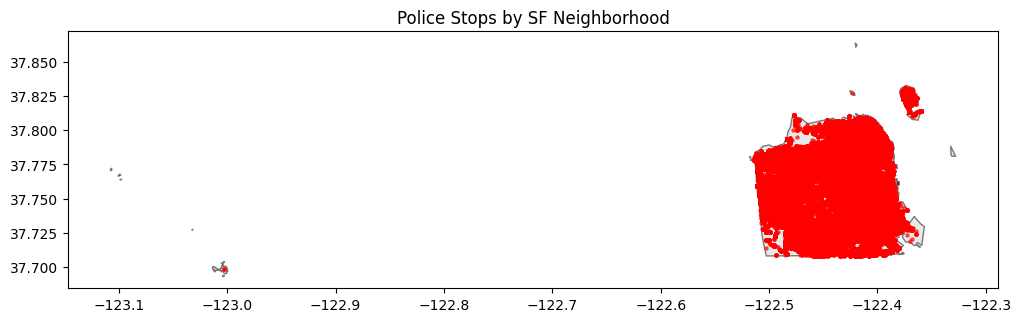

In [45]:
def fix_coordinates(stop_df, city_boundaries, counties_of_interest):

    # only keep data within relevant counties
    city_boundaries_filt = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
    
    
    # filter points to within bounaries of county polygon
    stops_clean = gpd.sjoin(stop_df, city_boundaries_filt, predicate="within")
     
    return stops_clean, city_boundaries_filt

stops_clean, city_boundaries_filt = fix_coordinates(stops_df, city_boundaries, counties_of_interest)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
city_boundaries_filt.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
stops_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()   

## Preprocess Non Location Variables

In [46]:
# Filtering time range from 2010 - 2016
stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean = stops_clean[(stops_clean['date'].dt.year >= 2010) & (stops_clean['date'].dt.year <= 2016)]
stops_clean.count()

raw_row_number                       575414
date                                 575414
time                                 575409
location                             575414
lat                                  575414
lng                                  575414
district                             523506
subject_age                          522220
subject_race                         575414
subject_sex                          575414
type                                 575414
arrest_made                          575414
citation_issued                      575414
warning_issued                       575414
outcome                              566464
contraband_found                      30696
search_conducted                     575414
search_vehicle                       575414
search_basis                          30696
reason_for_stop                      573562
raw_search_vehicle_description       575414
raw_result_of_contact_description    575414
geometry                        

In [47]:
# View number of outcomes for each variable of intreset
variables = ['district', 'outcome', 'subject_race', 'subject_sex', 'type', 'reason_for_stop', 'raw_search_vehicle_description', 'raw_result_of_contact_description']

for v in variables:
    print(stops_clean[v].value_counts(normalize=True, dropna=False))

district
H      0.119941
B      0.117979
I      0.106968
C      0.104761
D      0.095622
G      0.093759
NaN    0.090210
A      0.086235
E      0.070916
F      0.063507
J      0.048515
K      0.000671
S      0.000613
T      0.000302
Name: proportion, dtype: float64
outcome
citation    0.690600
warning     0.283387
NaN         0.015554
arrest      0.010459
Name: proportion, dtype: float64
subject_race
white                     0.399073
asian/pacific islander    0.174858
black                     0.164692
hispanic                  0.133450
other                     0.127927
Name: proportion, dtype: float64
subject_sex
male      0.708436
female    0.291564
Name: proportion, dtype: float64
type
vehicular    1.0
Name: proportion, dtype: float64
reason_for_stop
Moving Violation                                                                                                                                                                            0.627077
Mechanical or Non-Moving Violation (V

Based on tabling, the following is suggested:
*  Only keep following for raw vehicle description: 'Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search'
*  Only keep following for reason for stop: 'Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist'

Note the raw vehicle description helps dervive search outcome (based on if it's postive or negative outcome)

In [48]:
# Filter out values in raw vehicle description
raw_vehicle_desc_keep = ['Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search']
stops_clean = stops_clean[stops_clean['raw_search_vehicle_description'].isin(raw_vehicle_desc_keep)]

raw_reason_for_stop = ['Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist']
stops_clean = stops_clean[stops_clean['reason_for_stop'].isin(raw_reason_for_stop)]

Now lets filter out NA in  'subject_age', 'time', 'district'

In [49]:
stops_clean = stops_clean.dropna(subset = ['subject_age', 'time', 'district'])

Filter out years

In [50]:
#filter year
import datetime as dt

stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean['year'] = stops_clean['date'].dt.year

stops_clean = stops_clean[stops_clean['date'] > pd.to_datetime("January 1st, 2010")]
stops_clean = stops_clean[stops_clean['date'] < pd.to_datetime("July 1st, 2016")]
stops_clean["Vision Zero"] = stops_clean['date'] > pd.to_datetime("March 18th, 2014")

Add Census Track data

In [51]:
census_boundaries = census_boundaries.to_crs(stops_clean.crs)

stops_clean = stops_clean.drop(columns=["index_right"], errors="ignore")
census_boundaries = census_boundaries.drop(columns=["index_right"], errors="ignore")

stops_clean = gpd.sjoin(
    stops_clean,
    census_boundaries,
    how="left",
    predicate="within"
)

In [52]:
stops_clean.head()

,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,countyfp10,geoid10,name10,namelsad10,mtfcc10,funcstat10,aland10,awater10,intptlat10,intptlon10
359291,326925,2010-01-02,00:01:00,CAPP & 16TH,37.765117,-122.418727,D,19.0,other,male,...,075,06075020100,201,Census Tract 201,G5020,S,445726,0,+37.7686074,-122.4200011
359292,326994,2010-01-02,10:15:00,100 BLOCK HYDE STREET,37.781625,-122.415388,J,56.0,black,male,...,075,06075012402,124.02,Census Tract 124.02,G5020,S,359016,0,+37.7801250,-122.4177669
359294,326996,2010-01-02,10:36:00,E/B POST @ BAKER ST,37.784323,-122.438430,G,29.0,white,male,...,075,06075015500,155,Census Tract 155,G5020,S,312624,0,+37.7850923,-122.4341350
359295,326949,2010-01-02,01:04:00,CHURCH STREET / 16THSTREET,37.764523,-122.428678,D,51.0,other,male,...,075,06075020300,203,Census Tract 203,G5020,S,286072,0,+37.7649411,-122.4294368
359296,326997,2010-01-02,10:40:00,151 FARRALLONES,37.713868,-122.457730,I,54.0,white,male,...,075,06075031400,314,Census Tract 314,G5020,S,770611,0,+37.7147206,-122.4571446


# Crash Preprocessing

Fix Location Data

In [53]:
# filter city to county of interest
counties_of_interest = ["San Francisco"]

# get number of coordinates within bounds
city_filtered = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
print("Total points:", len(stops_df))

min_x = city_filtered.total_bounds[0]
max_x = city_filtered.total_bounds[2]
min_y = city_filtered.total_bounds[1]
max_y = city_filtered.total_bounds[3]

print(f"Longitude: {min_x}, {max_x}\nLatitude: {min_y}, {max_y}")

Total points: 905070
Longitude: -123.10802700119842, -122.32768100246903
Latitude: 37.69306499862042, 37.863425998396984


In [54]:
print(city_boundaries['county'].unique())

<StringArray>
[      'Alameda',  'Contra Costa',         'Marin',          'Napa',
 'San Francisco',     'San Mateo',   'Santa Clara',        'Solano',
        'Sonoma']
Length: 9, dtype: str


/var/folders/sz/kfl22r0s7v3bf055gpl9hxkr0000gn/T/ipykernel_983/1204626325.py:8: UserWarning:

Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




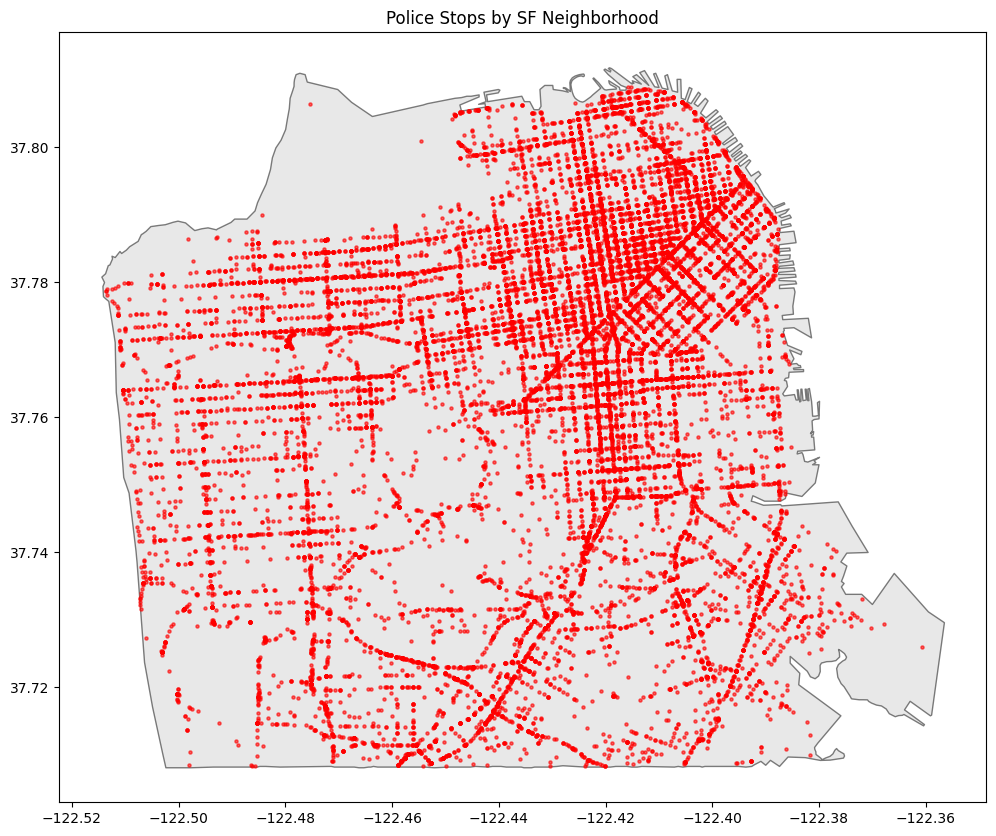

In [55]:
def fix_coordinates(stop_df, city_boundaries, counties_of_interest):

    # only keep data within relevant counties
    city_boundaries_filt = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
    
    # remove small disconnected polygons (e.g. Farallon Islands)
    city_boundaries_filt = city_boundaries_filt.explode(index_parts=False)
    city_boundaries_filt = city_boundaries_filt[city_boundaries_filt.geometry.area == city_boundaries_filt.geometry.area.max()]
    
    # filter points to within boundaries of county polygon
    stops_clean = gpd.sjoin(stop_df, city_boundaries_filt, predicate="within")
     
    return stops_clean, city_boundaries_filt

crash_clean, city_boundaries_filt = fix_coordinates(crash_df, city_boundaries, counties_of_interest)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
city_boundaries_filt.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
crash_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()

Filter out years

In [56]:
import datetime as dt

crash_clean['collision_datetime'] = pd.to_datetime(crash_clean['collision_datetime'])
crash_clean['year'] = crash_clean['collision_datetime'].dt.year

#crash_clean = crash_clean[crash_clean['collision_datetime'] > pd.to_datetime("January 1st, 2010")]
#crash_clean = crash_clean[crash_clean['collision_datetime'] < pd.to_datetime("July 1st, 2016")]
crash_clean["Vision Zero"] = crash_clean['collision_datetime'] > pd.to_datetime("March 18th, 2014")

<Axes: xlabel='year', ylabel='num_crashes'>

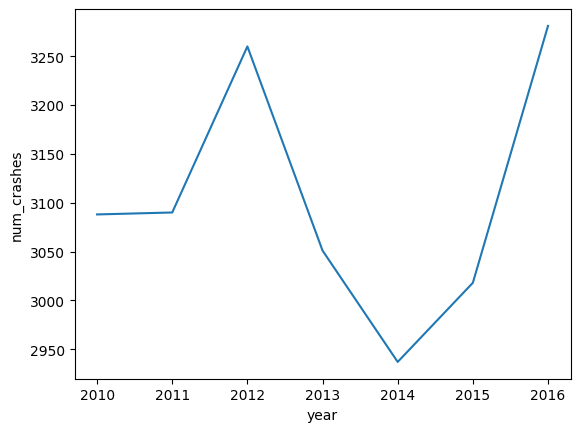

In [57]:
crashes_per_year = crash_clean.groupby('year').size().reset_index(name='num_crashes')
sns.lineplot(data=crashes_per_year, x='year', y='num_crashes')

Add census tract data

In [58]:
census_boundaries = census_boundaries.to_crs(crash_clean.crs)

crash_clean = crash_clean.drop(columns=["index_right"], errors="ignore")
census_boundaries = census_boundaries.drop(columns=["index_right"], errors="ignore")

crash_clean = gpd.sjoin(
    crash_clean,
    census_boundaries,
    how="left",
    predicate="within"
)

In [59]:
crash_clean.tail()

,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,countyfp10,geoid10,name10,namelsad10,mtfcc10,funcstat10,aland10,awater10,intptlat10,intptlon10
21870,41769,27952000,NaN,161062434,37.762238,-122.507130,SFPD-CROSSROADS,CITY STREET,2016-12-31 12:13:00,2016 December 31,...,075,06075035202,352.02,Census Tract 352.02,G5020,S,372475,0,+37.7613974,-122.5061466
21871,44090,27558000,NaN,161062967,37.779947,-122.487946,SFPD-CROSSROADS,CITY STREET,2016-12-31 16:33:00,2016 December 31,...,075,06075042700,427,Census Tract 427,G5020,S,408065,0,+37.7822651,-122.4881473
21872,39434,23194000,NaN,161063357,37.748692,-122.475017,SFPD-CROSSROADS,CITY STREET,2016-12-31 19:27:00,2016 December 31,...,075,06075030302,303.02,Census Tract 303.02,G5020,S,596628,0,+37.7519442,-122.4716376
21873,23311,33776000,8631000.0,170000035,37.787084,-122.389011,SFPD-CROSSROADS,CITY STREET,2016-12-31 23:16:00,2016 December 31,...,075,06075061500,615,Census Tract 615,G5020,S,1669699,439739,+37.7877258,-122.3923886
21874,29328,25192000,NaN,170000041,37.784753,-122.421193,SFPD-CROSSROADS,CITY STREET,2016-12-31 23:50:00,2016 December 31,...,075,06075012202,122.02,Census Tract 122.02,G5020,S,92784,0,+37.7854142,-122.4196438


# Visualizations

Looking at stops over time:

In [60]:
import ggplot

# get proportion of stops across years
stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean['year'] = stops_clean['date'].dt.year
year_counts = (
    stops_clean['year']
    .value_counts()
    .sort_index()
    .reset_index()
)
year_counts.columns = ['year', 'count']
year_counts['prop'] = year_counts['count'] / year_counts['count'].sum()

(
    ggplot(year_counts, aes(x='factor(year)', y='count')) +
    geom_col() +
    labs(
        x="Year",
        y="Stops",
        title="Number of Stops per Year"
    )
)

(
    ggplot(year_counts, aes(x='factor(year)', y='prop')) +
    geom_col() +
    labs(
        x="Year",
        y="Proportion of Observations",
        title="Proportion of Stops per Year"
    )
)

AttributeError: module 'pandas' has no attribute 'tslib'

In [ ]:
# Plot heatmap to show distribution of crashes and collisions from raw data
geojson = city_boundaries.__geo_interface__

# plot baselayer
fig = px.choropleth_map(
    city_boundaries,
    geojson=geojson,
    locations=city_boundaries.index,
    color_discrete_sequence=["lightgray"],
    map_style="carto-positron",
    zoom=8,
    center={"lat": 37.77, "lon": -122.42},
    opacity=0.4
)

# Police stop density
fig.add_trace(
    go.Densitymap(
        lat=stops_clean.geometry.y,
        lon=stops_clean.geometry.x,
        radius=10, 
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Stops"
    )
)

fig.update_layout(
    title="Police Stops and Collisions Density",
    hovermode=False,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

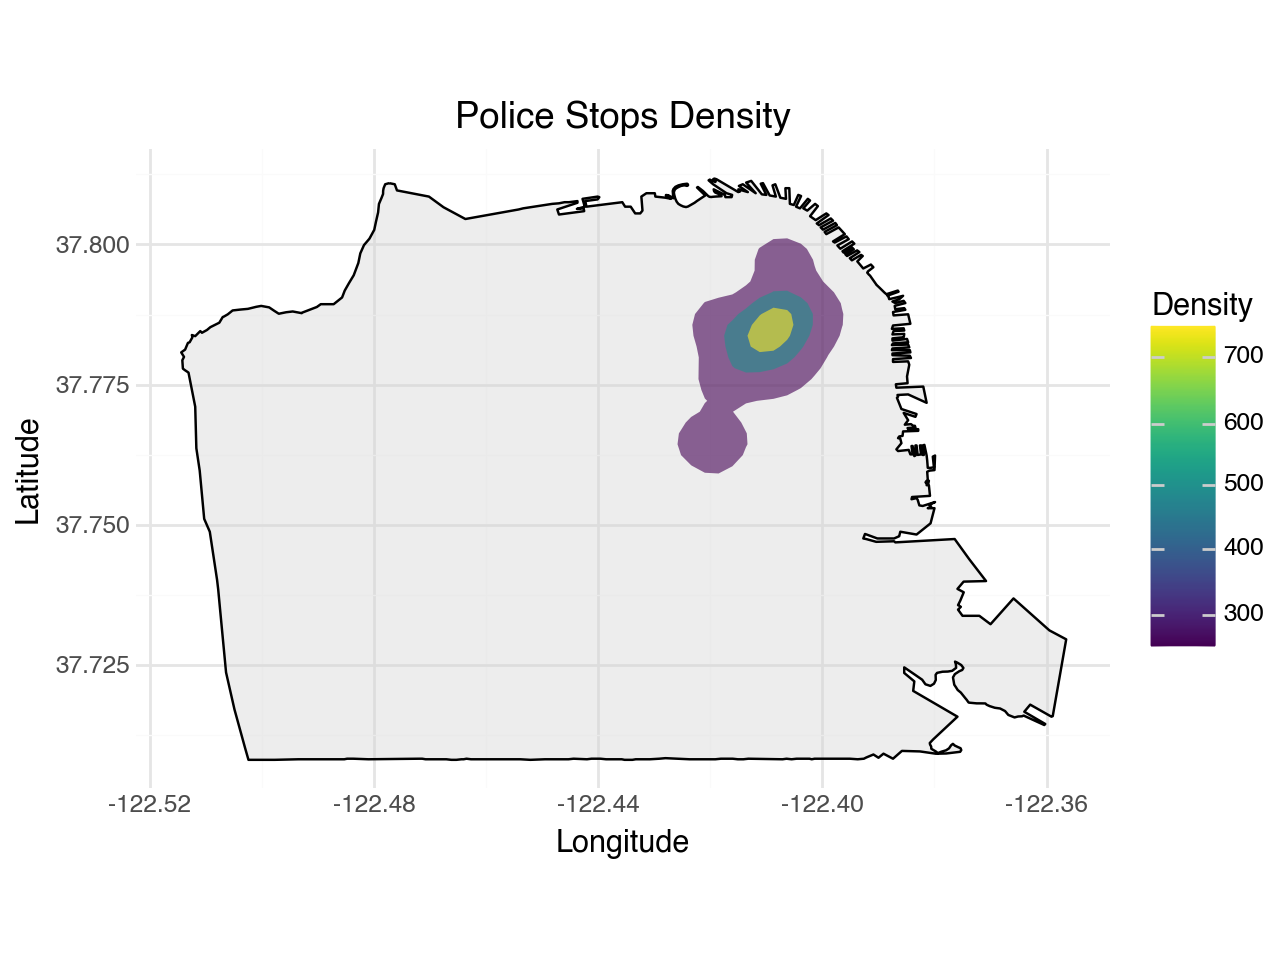

In [ ]:
stops_clean = stops_clean.to_crs(city_boundaries_filt.crs)
stops_clean["lon"] = stops_clean.geometry.x
stops_clean["lat"] = stops_clean.geometry.y

(
    ggplot() +
    # City boundary (base layer)
    geom_map(
        city_boundaries_filt,
         aes(map_id="county"),
        fill="lightgray",
        color="black",
        alpha=0.4
    ) +
    # Density heatmap layer
    stat_density_2d(
        stops_clean,
        aes(x="lon", y="lat", fill="..level.."),
        geom="polygon",
        alpha=0.6,
        contour=True
    ) +
    scale_fill_cmap(name="Density", cmap_name="viridis") +
    labs(
        title="Police Stops Density",
        x="Longitude",
        y="Latitude"
    ) +
    coord_equal() +
    theme_minimal()
)

## Processing Years

In [ ]:
import datetime as dt

stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean['year'] = stops_clean['date'].dt.year
stops_clean['month'] = stops_clean['date'].dt.month

#idenitify dates before and after Vision Zero was adpoted on March 18th 2014
stops_clean['Vision_Zero_Status'] = stops_clean['date'] > pd.to_datetime('March 18th, 2014')

stops_clean.head()

,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,namelsad10,mtfcc10,funcstat10,aland10,awater10,intptlat10,intptlon10,lon,month,Vision_Zero_Status
359291,326925,2010-01-02,00:01:00,CAPP & 16TH,37.765117,-122.418727,D,19.0,other,male,...,Census Tract 201,G5020,S,445726,0,+37.7686074,-122.4200011,-122.418727,1,False
359292,326994,2010-01-02,10:15:00,100 BLOCK HYDE STREET,37.781625,-122.415388,J,56.0,black,male,...,Census Tract 124.02,G5020,S,359016,0,+37.7801250,-122.4177669,-122.415388,1,False
359294,326996,2010-01-02,10:36:00,E/B POST @ BAKER ST,37.784323,-122.438430,G,29.0,white,male,...,Census Tract 155,G5020,S,312624,0,+37.7850923,-122.4341350,-122.438430,1,False
359295,326949,2010-01-02,01:04:00,CHURCH STREET / 16THSTREET,37.764523,-122.428678,D,51.0,other,male,...,Census Tract 203,G5020,S,286072,0,+37.7649411,-122.4294368,-122.428678,1,False
359296,326997,2010-01-02,10:40:00,151 FARRALLONES,37.713868,-122.457730,I,54.0,white,male,...,Census Tract 314,G5020,S,770611,0,+37.7147206,-122.4571446,-122.457730,1,False


In [ ]:
stops_clean.groupby(['year', 'Vision_Zero_Status']).size()


year  Vision_Zero_Status
2010  False                 63095
2011  False                 63836
2012  False                 53543
2013  False                 47042
2014  False                 13218
      True                  12093
2015  True                  54128
2016  True                  26153
dtype: int64

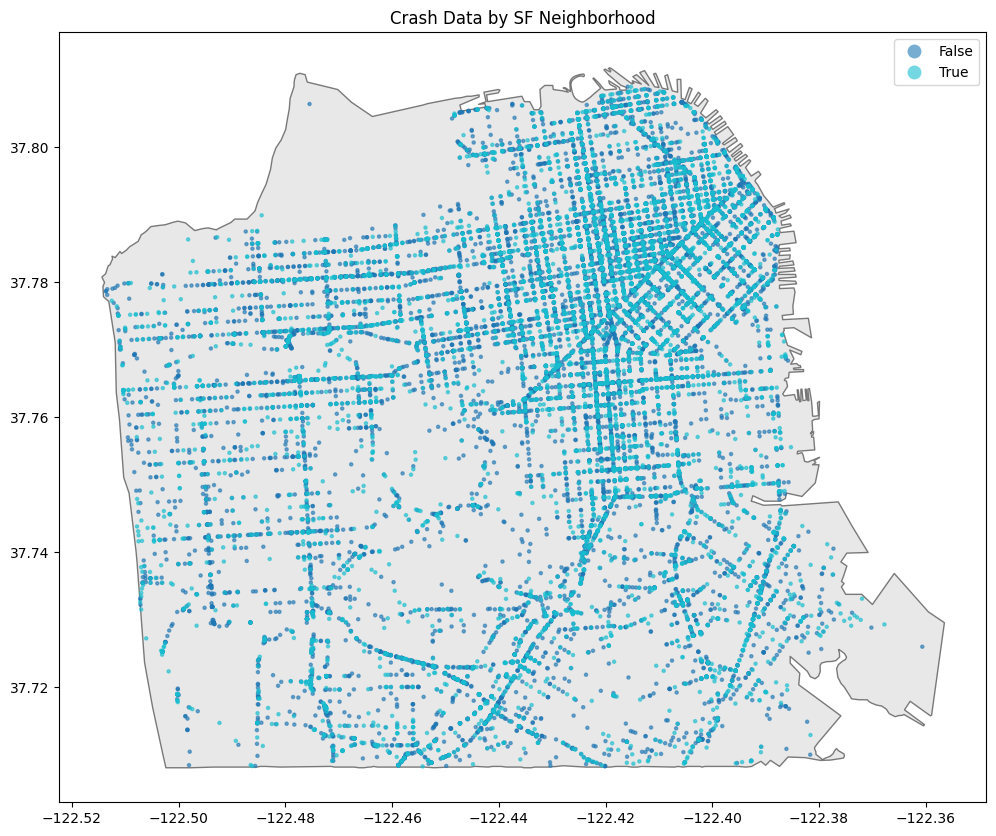

In [ ]:
# see what data looks like when outcome = NA (none of warning, citation, arrest)
fig, ax = plt.subplots(figsize=(12, 10))
city_boundaries_filt.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
crash_clean.plot(ax=ax, column='Vision Zero', markersize=5, alpha=0.6, legend=True, categorical=True)
plt.title("Crash Data by SF Neighborhood")
plt.show()   

In [ ]:
crash_clean['police_district'].value_counts(dropna=False)

police_district
SOUTHERN      3300
NORTHERN      3057
MISSION       2751
TARAVAL       2288
RICHMOND      1795
INGLESIDE     1782
CENTRAL       1740
BAYVIEW       1530
PARK          1235
TENDERLOIN     558
NaN             14
Name: count, dtype: int64

## Looking at crashes and stops over time

Text(0.5, 1.0, 'Number of Police Stops and Crashes per Year')

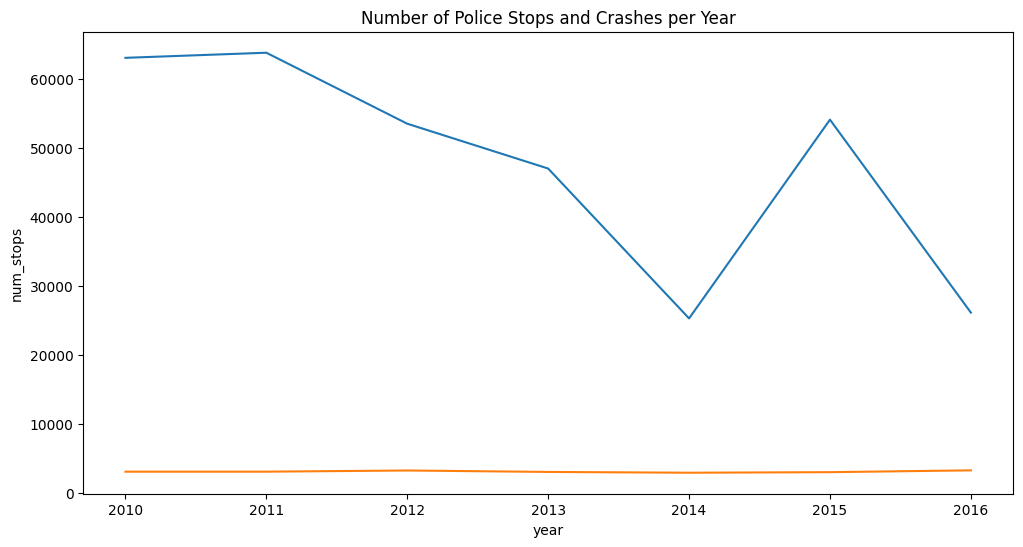

In [ ]:
import seaborn as sns

# Extract date col
stops_clean['date'] = pd.to_datetime(stops_clean['date'])
stops_clean['year'] = stops_clean['date'].dt.year

crash_clean['collision_date'] = pd.to_datetime(crash_clean['collision_date'])
crash_clean['year'] = crash_clean['collision_date'].dt.year

stops_per_year = stops_clean.groupby('year').size().reset_index(name='num_stops')
crashes_per_year = crash_clean.groupby('year').size().reset_index(name='num_crashes')

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=stops_per_year, x='year', y='num_stops')
sns.lineplot(data=crashes_per_year, x='year', y='num_crashes')
plt.title("Number of Police Stops and Crashes per Year")

<Axes: xlabel='year', ylabel='num_crashes'>

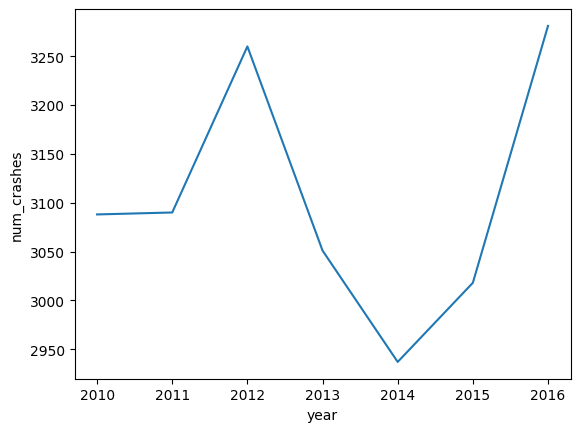

In [ ]:
sns.lineplot(data=crashes_per_year, x='year', y='num_crashes')

## Filtering out columns

In [ ]:
cols_to_keep_stops = [
    'date', 'time', 'month', 'year', 'Vision_Zero_Status',
    'geometry', 'lat', 'lng', 'district',
    'subject_age', 'subject_race', 'subject_sex',
    'type', 'arrest_made', 'citation_issued', 'warning_issued', 
    'outcome', 'contraband_found', 'search_conducted', 
    'search_vehicle', 'search_basis', 'reason_for_stop', 'raw_search_vehicle_description'
]

stops_model = stops_clean[cols_to_keep_stops]
stops_model.head()

,date,time,month,year,Vision_Zero_Status,geometry,lat,lng,district,subject_age,...,arrest_made,citation_issued,warning_issued,outcome,contraband_found,search_conducted,search_vehicle,search_basis,reason_for_stop,raw_search_vehicle_description
359291,2010-01-02,00:01:00,1,2010,False,POINT (-122.41873 37.76512),37.765117,-122.418727,D,19.0,...,False,False,True,warning,NaN,False,False,NaN,Moving Violation,No Search
359292,2010-01-02,10:15:00,1,2010,False,POINT (-122.41539 37.78163),37.781625,-122.415388,J,56.0,...,False,False,True,warning,NaN,False,False,NaN,Moving Violation,No Search
359294,2010-01-02,10:36:00,1,2010,False,POINT (-122.43843 37.78432),37.784323,-122.438430,G,29.0,...,False,True,False,citation,NaN,False,False,NaN,Moving Violation,No Search
359295,2010-01-02,01:04:00,1,2010,False,POINT (-122.42868 37.76452),37.764523,-122.428678,D,51.0,...,False,True,False,citation,NaN,False,False,NaN,Moving Violation,No Search
359296,2010-01-02,10:40:00,1,2010,False,POINT (-122.45773 37.71387),37.713868,-122.457730,I,54.0,...,False,False,True,warning,NaN,False,False,NaN,Moving Violation,No Search


## Ignore the next two chunks

I already created the embedded column and saved it
The Glo Ve zip file was too large for github
We can just load in the column

In [ ]:
import numpy as np
import zipfile

# Glo VE Embeddings

def load_glove(glove_path):
    embeddings = {}
    with zipfile.ZipFile(glove_path, 'r') as z:
        # Get the first .txt file inside the zip
        txt_file = [f for f in z.namelist() if f.endswith('.txt')][0]
        with z.open(txt_file) as f:
            for line in f:
                values = line.decode('utf-8').split()
                word = values[0]
                vector = np.array(values[1:], dtype='float32')
                embeddings[word] = vector
    return embeddings

glove_path = r"../Preprocessing/glove.6B.zip"
glove = load_glove(glove_path)

In [ ]:
def embed_text(text, glove_dict, dim=100):
    if not isinstance(text, str):
        return np.zeros(dim)
    
    tokens = text.lower().split()
    vectors = [glove_dict[word] for word in tokens if word in glove_dict]
    
    if not vectors:
        return np.zeros(dim)  # return zero vector if no known words
    
    return np.mean(vectors, axis=0)

In [ ]:
dim = len(next(iter(glove.values())))
print(f"Dimensions: {dim}")

Dimensions: 50


In [ ]:
dim = 50  # match your GloVe file

stops_model['glove_embedding_raw_search_vehicle_description'] = stops_model['raw_search_vehicle_description'].apply(
    lambda x: embed_text(x, glove, dim=dim)
)

In [ ]:
import pickle

# Save the embedded column as a pickle file
stops_model['glove_embedding_raw_search_vehicle_description'].to_pickle('vehicle_glove_embeddings.pkl')

In [ ]:
# Fixing NA values
stops_model['outcome'] = stops_model['outcome'].fillna('Unknown')
stops_model['contraband_found'] = stops_model['contraband_found'].fillna('Unknown')
stops_model['search_basis'] = stops_model['search_basis'].fillna('Unknown')

In [ ]:
cols_to_keep_crash = [
    'collision_date', 'collision_time', 'accident_year', 'month', 'day_of_week', 'time_cat', 'Vision Zero',
    'number_killed', 'number_injured', 'collision_severity', 'type_of_collision',
    'geometry', 'tb_latitude', 'tb_longitude', 'analysis_neighborhood',
    'police_district', 'supervisor_district', 'primary_rd', 'secondary_rd', 'intersection',
    'weather_1', 'road_surface', 'road_cond_1', 'lighting', 'control_device',
    'vz_pcf_group', 'vz_pcf_description',
    'party_at_fault', 'party1_type', 'party2_type', 'ped_action', 'mviw'
]

crash_model = crash_clean[cols_to_keep_crash]
crash_model.head()

,collision_date,collision_time,accident_year,month,day_of_week,time_cat,Vision Zero,number_killed,number_injured,collision_severity,...,road_cond_1,lighting,control_device,vz_pcf_group,vz_pcf_description,party_at_fault,party1_type,party2_type,ped_action,mviw
9241,2010 January 01,02:06:00,2010,January,Friday,2:01 am to 6:00 am,False,0.0,2,Injury (Complaint of Pain),...,No Unusual Condition,Dark - Street Lights,Functioning,22350,Unsafe speed for prevailing conditions,1.0,Driver,Driver,No Pedestrian Involved,Other Motor Vehicle
9242,2010 January 01,02:38:00,2010,January,Friday,2:01 am to 6:00 am,False,0.0,1,Injury (Complaint of Pain),...,No Unusual Condition,Dark - Street Lights,NaN,22350,Unsafe speed for prevailing conditions,1.0,Driver,NaN,No Pedestrian Involved,Fixed Object
9243,2010 January 01,16:30:00,2010,January,Friday,2:01 pm to 6:00 pm,False,0.0,1,Injury (Other Visible),...,No Unusual Condition,Daylight,Functioning,"21950(a,c)",Driver or bicyclist to yield right-of-way at c...,1.0,Driver,Pedestrian,Crossing in Crosswalk at Intersection,Pedestrian
9244,2010 January 01,18:59:00,2010,January,Friday,6:01 pm to 10:00 pm,False,0.0,1,Injury (Complaint of Pain),...,No Unusual Condition,Dark - Street Lights,Functioning,"21950(a,c)",Driver or bicyclist to yield right-of-way at c...,1.0,Driver,Pedestrian,Crossing in Crosswalk at Intersection,Pedestrian
9245,2010 January 02,16:50:00,2010,January,Saturday,2:01 pm to 6:00 pm,False,0.0,1,Injury (Other Visible),...,No Unusual Condition,Dusk - Dawn,NaN,22350,Unsafe speed for prevailing conditions,1.0,Driver,NaN,No Pedestrian Involved,Fixed Object
